You are a junior ML engineer at
SmartForge Manufacturing. The production line images thousands of steel strips
every day. Manual visual inspection is slow, inconsistent, and misses subtle
defects that cause costly downstream failures. The engineering team needs two
things: (1) a model that can identify which type of defect is present, and (2)
evidence that the model is robust enough to handle real production variability
(different lighting, orientations, and surface conditions). Your job is to
build and harden that model using PyTorch.

In [ ]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 15.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 31.9 MB/s eta 0:00:00


In [ ]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import StepLR


import os
from PIL import Image

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import optuna

from sklearn.metrics import classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')


# Dataset

NEU Surface Defect Database (Kaggle) — 1,800 grayscale
images (200×200 px) of steel strip surfaces
6 defect classes: rolled-in scale (RS), patches (Pa),
crazing (Cr), pitted surface (PS), inclusion (In), scratches (Sc)
300 images per class — balanced dataset
Access:  

https://www.kaggle.com/datasets/kaustubhdikshit/neu-surface-defect-database (load with
torchvision.datasets.ImageFolder)

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

import zipfile

zip_path = "/content/drive/MyDrive/Colab Notebooks/archive.zip"
extract_path = "/content/dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction completed!")


data_dir = "/content/dataset/NEU-DET"
train_dir = "/content/dataset/NEU-DET/train/images"
val_dir = "/content/dataset/NEU-DET/validation/images"

for root, dirs, files in os.walk(data_dir):
    print(root, len(files))

inp_size = 64
input_dim = inp_size ** 2

torch.manual_seed(42)
np.random.seed(42)

Mounted at /content/drive
Extraction completed!
/content/dataset/NEU-DET 0
/content/dataset/NEU-DET/validation 0
/content/dataset/NEU-DET/validation/images 0
/content/dataset/NEU-DET/validation/images/pitted_surface 60
/content/dataset/NEU-DET/validation/images/rolled-in_scale 60
/content/dataset/NEU-DET/validation/images/crazing 60
/content/dataset/NEU-DET/validation/images/patches 60
/content/dataset/NEU-DET/validation/images/inclusion 60
/content/dataset/NEU-DET/validation/images/scratches 60
/content/dataset/NEU-DET/validation/annotations 361
/content/dataset/NEU-DET/train 0
/content/dataset/NEU-DET/train/images 0
/content/dataset/NEU-DET/train/images/pitted_surface 240
/content/dataset/NEU-DET/train/images/rolled-in_scale 240
/content/dataset/NEU-DET/train/images/crazing 240
/content/dataset/NEU-DET/train/images/patches 240
/content/dataset/NEU-DET/train/images/inclusion 240
/content/dataset/NEU-DET/train/images/scratches 240
/content/dataset/NEU-DET/train/annotations 1439


In [ ]:
transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((inp_size, inp_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5],std=[0.5]),
])


train_dataset = datasets.ImageFolder(train_dir, transform=transform)
val_dataset = datasets.ImageFolder(val_dir, transform=transform)


train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)


num_classes = len(train_dataset.classes)

print(train_dataset.classes)
print(train_dataset.class_to_idx)
print(len(train_dataset), len(val_dataset))

['crazing', 'inclusion', 'patches', 'pitted_surface', 'rolled-in_scale', 'scratches']
{'crazing': 0, 'inclusion': 1, 'patches': 2, 'pitted_surface': 3, 'rolled-in_scale': 4, 'scratches': 5}
1440 360


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Device : {device}")
print(f"PyTorch version : {torch.__version__}")
print(f"CUDA version : {torch.version.cuda}")

Device : cuda
PyTorch version : 2.11.0+cu128
CUDA version : 12.8


# Part 0: NN Foundations

### 1 Implement a simple 2-layer neural network from scratch using nn.Module — no nn.Sequential shortcuts. Define __init__ and forward explicitly.


In [ ]:
class SimpleNN(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_classes, activation="relu"):
        super(SimpleNN, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.act = nn.ReLU() if activation == "relu" else nn.Sigmoid()
        self.fc2 = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        x = x.view(x.size(0),-1)
        x = self.fc1(x)
        x = self.act(x)
        x = self.fc2(x)
        return x

model = SimpleNN(input_dim = input_dim, hidden_dim=128, num_classes=num_classes, activation="relu").to(device)
print(model)


SimpleNN(
  (fc1): Linear(in_features=4096, out_features=128, bias=True)
  (act): ReLU()
  (fc2): Linear(in_features=128, out_features=6, bias=True)
)


In [ ]:
def train_model(model, train_loader, epochs=20, lr=0.01):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=lr)

    losses = []
    model.train()

    for epoch in range(epochs):
        running_loss = 0.0
        for images,labels  in train_loader:
            images,labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            output = model(images)
            loss = criterion(output, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
        avg_loss = running_loss / len(train_loader)
        losses.append(avg_loss)
        print(f"Epoch {epoch + 1}/{epochs} - Loss : {avg_loss:4f}")
    return losses

### 2. Activation functions: swap ReLU for Sigmoid in your hidden layer and compare convergence over 20 epochs. What do you notice?

In [ ]:
model_relu = SimpleNN(input_dim = input_dim, hidden_dim=128, num_classes=num_classes, activation="relu").to(device)
losses_relu = train_model(model_relu, train_loader, 20)

Epoch 1/20 - Loss : 1.604997
Epoch 2/20 - Loss : 1.504629
Epoch 3/20 - Loss : 1.449911
Epoch 4/20 - Loss : 1.404856
Epoch 5/20 - Loss : 1.365798
Epoch 6/20 - Loss : 1.328820
Epoch 7/20 - Loss : 1.295859
Epoch 8/20 - Loss : 1.263700
Epoch 9/20 - Loss : 1.233732
Epoch 10/20 - Loss : 1.207156
Epoch 11/20 - Loss : 1.183502
Epoch 12/20 - Loss : 1.157097
Epoch 13/20 - Loss : 1.135199
Epoch 14/20 - Loss : 1.110551
Epoch 15/20 - Loss : 1.089531
Epoch 16/20 - Loss : 1.067400
Epoch 17/20 - Loss : 1.046112
Epoch 18/20 - Loss : 1.029687
Epoch 19/20 - Loss : 1.008007
Epoch 20/20 - Loss : 0.990245


In [ ]:
model_sigmoid = SimpleNN(input_dim = input_dim, hidden_dim=128, num_classes=num_classes, activation="sigmoid").to(device)

losses_sigmoid = train_model(model_sigmoid, train_loader, 20)

Epoch 1/20 - Loss : 1.720238
Epoch 2/20 - Loss : 1.621362
Epoch 3/20 - Loss : 1.584634
Epoch 4/20 - Loss : 1.563164
Epoch 5/20 - Loss : 1.546453
Epoch 6/20 - Loss : 1.534908
Epoch 7/20 - Loss : 1.524978
Epoch 8/20 - Loss : 1.515738
Epoch 9/20 - Loss : 1.507259
Epoch 10/20 - Loss : 1.497533
Epoch 11/20 - Loss : 1.489498
Epoch 12/20 - Loss : 1.480372
Epoch 13/20 - Loss : 1.472921
Epoch 14/20 - Loss : 1.464627
Epoch 15/20 - Loss : 1.456799
Epoch 16/20 - Loss : 1.450020
Epoch 17/20 - Loss : 1.441966
Epoch 18/20 - Loss : 1.434092
Epoch 19/20 - Loss : 1.426699
Epoch 20/20 - Loss : 1.419099


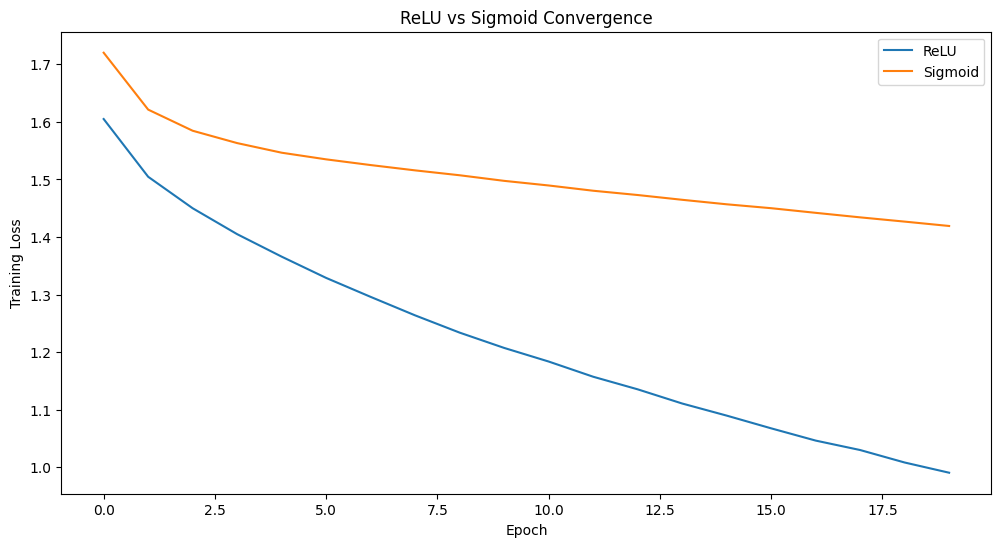

In [ ]:
plt.figure(figsize=(12,6))

plt.plot(losses_relu, label="ReLU")
plt.plot(losses_sigmoid, label="Sigmoid")

plt.xlabel('Epoch')
plt.ylabel('Training Loss')
plt.title('ReLU vs Sigmoid Convergence')
plt.legend()
plt.show()

**ReLU vs Sigmoid convergence:** ReLU drops from loss 1.60 to less than 1 over 20 epochs. Sigmoid only reaches to about 1.4, moving much more sluggishly per epoch. This is the classic vanishing-gradient signature: Sigmoid's derivative maxes out at 0.25 and shrinks toward zero at the extremes, so gradients flowing back through it shrink at every step, while ReLU's gradient is a clean 0 or 1, letting error signal propagate essentially undamped.

### 3. Loss function choice: train with nn.CrossEntropyLoss.

Why is this preferred over nn.MSELoss for multi-class defect classification?


 **CrossEntropy vs MSE**: CrossEntropyLoss is preferred for multi-class classification because it directly measures how much probability mass the model assigns to the correct class and produces strong, well-behaved gradients even for confidently wrong predictions. MSE treats outputs as continuous regression targets, requires one-hot encoding, and gives comparatively weak gradients when predictions are very wrong. It doesn't match the probabilistic, mutually-exclusive structure of a classification problem the way CrossEntropy does.

### 4. Optimizer comparison: train the same network three times — torch.optim.SGD, SGD with momentum=0.9, and Adam. Plot all three loss curves on one graph. Which converges fastest? Estimate the GPU memory each optimizer requires for this model.

In [ ]:
def train_with_optimizer(model, train_loader, optimizer, epochs=20, lr=0.01):
    criterion = nn.CrossEntropyLoss()

    losses = []
    model.train()

    for epoch in range(epochs):
        running_loss = 0.0
        for images,labels  in train_loader:
            images,labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            output = model(images)
            loss = criterion(output, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        losses.append(running_loss / len(train_loader))
        print(f"Epoch {epoch + 1}/{epochs} - Loss : {losses[-1]:4f}")
    return losses

In [ ]:
print("Optimizer - SGD")
model_sgd = SimpleNN(input_dim, 128, num_classes).to(device)
opt_sgd = optim.SGD(model_sgd.parameters(), lr=0.01)
losses_sgd = train_with_optimizer(model_sgd, train_loader, opt_sgd)


print("Optimizer - SGD + Momentum")
model_mom = SimpleNN(input_dim, 128, num_classes).to(device)
opt_mom = optim.SGD(model_mom.parameters(), lr=0.01, momentum=0.9)
losses_mom = train_with_optimizer(model_mom, train_loader, opt_mom)


print("Optimizer - Adam")
model_adam = SimpleNN(input_dim, 128, num_classes).to(device)
opt_adam = optim.Adam(model_adam.parameters(), lr=0.001)
losses_adam = train_with_optimizer(model_adam, train_loader, opt_adam)

Optimizer - SGD
Epoch 1/20 - Loss : 1.612309
Epoch 2/20 - Loss : 1.502895
Epoch 3/20 - Loss : 1.445876
Epoch 4/20 - Loss : 1.396960
Epoch 5/20 - Loss : 1.357030
Epoch 6/20 - Loss : 1.315843
Epoch 7/20 - Loss : 1.282678
Epoch 8/20 - Loss : 1.250525
Epoch 9/20 - Loss : 1.220657
Epoch 10/20 - Loss : 1.194383
Epoch 11/20 - Loss : 1.168011
Epoch 12/20 - Loss : 1.142238
Epoch 13/20 - Loss : 1.120585
Epoch 14/20 - Loss : 1.099873
Epoch 15/20 - Loss : 1.079272
Epoch 16/20 - Loss : 1.059069
Epoch 17/20 - Loss : 1.039595
Epoch 18/20 - Loss : 1.019643
Epoch 19/20 - Loss : 1.002270
Epoch 20/20 - Loss : 0.985975
Optimizer - SGD + Momentum
Epoch 1/20 - Loss : 1.482062
Epoch 2/20 - Loss : 1.206317
Epoch 3/20 - Loss : 1.066990
Epoch 4/20 - Loss : 0.955018
Epoch 5/20 - Loss : 0.873278
Epoch 6/20 - Loss : 0.815233
Epoch 7/20 - Loss : 0.753283
Epoch 8/20 - Loss : 0.707262
Epoch 9/20 - Loss : 0.665736
Epoch 10/20 - Loss : 0.616683
Epoch 11/20 - Loss : 0.627727
Epoch 12/20 - Loss : 0.542445
Epoch 13/20 - L

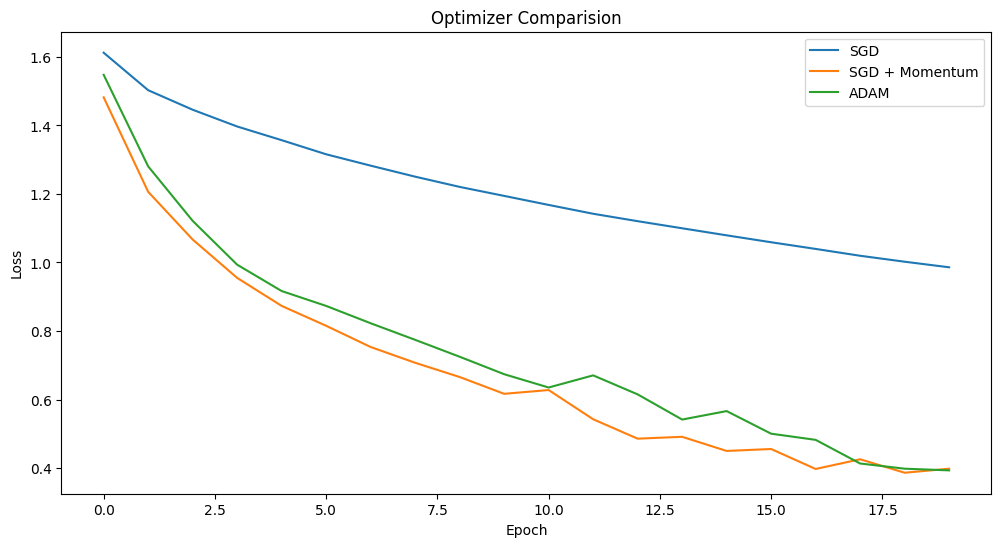

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(losses_sgd, label="SGD")
plt.plot(losses_mom, label="SGD + Momentum")
plt.plot(losses_adam, label="ADAM")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Optimizer Comparision")
plt.legend()
plt.show()

In [ ]:
num_params = sum(params.numel() for params in model_sgd.parameters())
bytes_per_params = 4

mem_sgd = num_params * bytes_per_params * 2  # params + grad
mem_mom = num_params * bytes_per_params * 3  # params + grad + momentum buffer
mem_adam = num_params * bytes_per_params * 4 # params + grad + 2 * momentum buffer

print(f"Total parameters: {num_params:,}")
print(f"SGD memory:      ~{mem_sgd/1024:.1f} KB")
print(f"Momentum memory: ~{mem_mom/1024:.1f} KB")
print(f"Adam memory:     ~{mem_adam/1024:.1f} KB")


Total parameters: 525,190
SGD memory:      ~4103.0 KB
Momentum memory: ~6154.6 KB
Adam memory:     ~8206.1 KB


**Optimizer comparison:** Final losses after 20 epochs: SGD 0.986, SGD+Momentum 0.398, Adam 0.393. Adam and SGD+Momentum converge dramatically faster and reach far lower loss than plain SGD. Adam's adaptive per-parameter scaling and momentum's velocity accumulation both help escape the slow, uniform-step-size behavior of vanilla SGD. GPU memory (525,190 params, float32): SGD ≈ 4.1 MB (params+grad), Momentum ≈ 6.2 MB (+velocity buffer), Adam ≈ 8.2 MB (+2 moment buffers). Adam costs roughly 2x plain SGD's memory footprint for this model.

### 5. Training stability: add nn.BatchNorm1d after your hidden layer OR nn.Dropout(0.3). Re-train and report the effect on validation loss. Explain why the technique produces the effect you observe.

In [ ]:
class SimpleNNBatchNorm(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_classes):
        super(SimpleNNBatchNorm, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.bn = nn.BatchNorm1d(hidden_dim)
        self.act = nn.ReLU()
        self.fc2 = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = self.fc1(x)
        x = self.bn(x)
        x = self.act(x)
        x = self.fc2(x)
        return x

def evaluate(model, loader, criterion):
    total_loss = 0.0
    model.eval()
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)
        total_loss += loss.item()
    return total_loss / len(loader)


def train_and_validate(model, train_loader, val_loader, epochs=20, lr=0.01):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=lr)

    train_losses = []
    val_losses = []

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        train_losses.append(running_loss / len(train_loader))
        val_losses.append(evaluate(model, val_loader, criterion))

        print(f"Epoch {epoch+1}/{epochs}\t|\t"
          f"Train Loss: {train_losses[-1]:.4f}\t|\tVal Loss: {val_losses[-1]:.4f}")

    return train_losses, val_losses

Epoch 1/20	|	Train Loss: 1.6069	|	Val Loss: 1.6488
Epoch 2/20	|	Train Loss: 1.5109	|	Val Loss: 1.6385
Epoch 3/20	|	Train Loss: 1.4581	|	Val Loss: 1.5842
Epoch 4/20	|	Train Loss: 1.4089	|	Val Loss: 1.5551
Epoch 5/20	|	Train Loss: 1.3674	|	Val Loss: 1.5223
Epoch 6/20	|	Train Loss: 1.3292	|	Val Loss: 1.4855
Epoch 7/20	|	Train Loss: 1.2959	|	Val Loss: 1.4602
Epoch 8/20	|	Train Loss: 1.2643	|	Val Loss: 1.4664
Epoch 9/20	|	Train Loss: 1.2385	|	Val Loss: 1.3977
Epoch 10/20	|	Train Loss: 1.2115	|	Val Loss: 1.3857
Epoch 11/20	|	Train Loss: 1.1862	|	Val Loss: 1.3614
Epoch 12/20	|	Train Loss: 1.1637	|	Val Loss: 1.3444
Epoch 13/20	|	Train Loss: 1.1389	|	Val Loss: 1.3318
Epoch 14/20	|	Train Loss: 1.1161	|	Val Loss: 1.3613
Epoch 15/20	|	Train Loss: 1.0960	|	Val Loss: 1.3394
Epoch 16/20	|	Train Loss: 1.0746	|	Val Loss: 1.3187
Epoch 17/20	|	Train Loss: 1.0561	|	Val Loss: 1.2990
Epoch 18/20	|	Train Loss: 1.0368	|	Val Loss: 1.2964
Epoch 19/20	|	Train Loss: 1.0192	|	Val Loss: 1.3086
Epoch 20/20	|	Train L

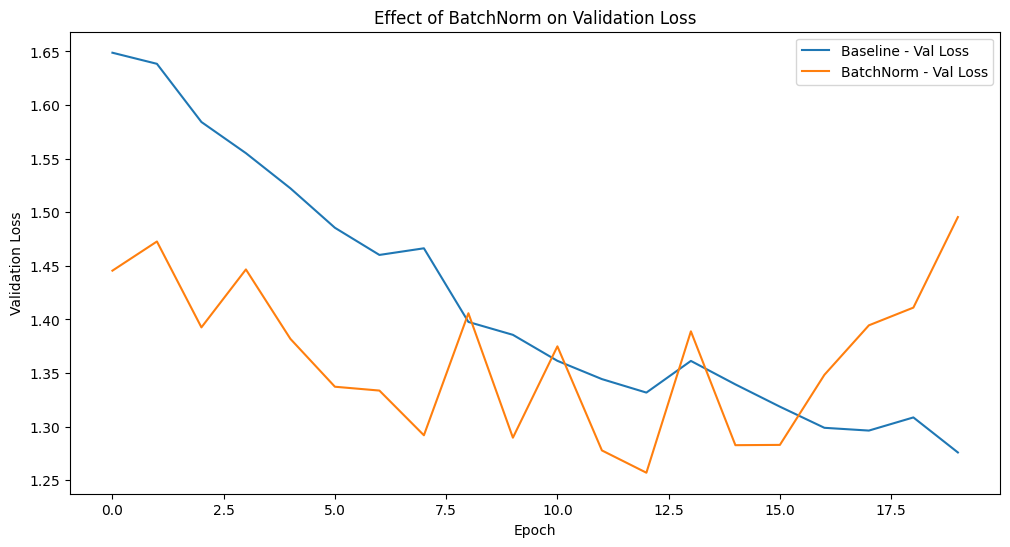

In [ ]:
model_baseline = SimpleNN(input_dim, 128, num_classes).to(device)
model_bn = SimpleNNBatchNorm(input_dim, 128, num_classes).to(device)

train_base, val_base = train_and_validate(model_baseline, train_loader, val_loader)
train_bn, val_bn = train_and_validate(model_bn, train_loader, val_loader)

plt.figure(figsize=(12,6))
plt.plot(val_base, label="Baseline - Val Loss")
plt.plot(val_bn, label="BatchNorm - Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Effect of BatchNorm on Validation Loss")
plt.legend()
plt.show()

**BatchNorm1d effect:** Baseline val loss falls fairly smoothly from 1.65 to 1.28 by epoch 20. The BatchNorm model starts lower (1.45) and also ends lower (1.28-1.50, noisier), reaching its best point around epoch 13 (1.257) before drifting back up. BatchNorm normalizes each hidden unit's activations to have stable mean/variance within each batch, keeping the layer's input distribution consistent as earlier weights update ("reducing internal covariate shift"). This speeds up early convergence, though per-batch statistics on a small dataset introduce some noise into later epochs.

# Part A: Defect Type Classifier


### 1.  Load the NEU dataset using torchvision.datasets.ImageFolder and torch.utils.data.DataLoader. How many images per class? What are the image dimensions?

In [ ]:
for roots, dirs, files in os.walk(data_dir):
    print(roots, len(files))

/content/dataset/NEU-DET 0
/content/dataset/NEU-DET/validation 0
/content/dataset/NEU-DET/validation/images 0
/content/dataset/NEU-DET/validation/images/pitted_surface 60
/content/dataset/NEU-DET/validation/images/rolled-in_scale 60
/content/dataset/NEU-DET/validation/images/crazing 60
/content/dataset/NEU-DET/validation/images/patches 60
/content/dataset/NEU-DET/validation/images/inclusion 60
/content/dataset/NEU-DET/validation/images/scratches 60
/content/dataset/NEU-DET/validation/annotations 361
/content/dataset/NEU-DET/train 0
/content/dataset/NEU-DET/train/images 0
/content/dataset/NEU-DET/train/images/pitted_surface 240
/content/dataset/NEU-DET/train/images/rolled-in_scale 240
/content/dataset/NEU-DET/train/images/crazing 240
/content/dataset/NEU-DET/train/images/patches 240
/content/dataset/NEU-DET/train/images/inclusion 240
/content/dataset/NEU-DET/train/images/scratches 240
/content/dataset/NEU-DET/train/annotations 1439


In [ ]:
sample_cls = os.listdir(train_dir)[0]
sample_path = os.path.join(train_dir, sample_cls)
sample_file =  os.listdir(sample_path)[0]

img = Image.open(os.path.join(sample_path, sample_file))
print(f"Sample image size : {img.size}, mode: {img.mode}")

Sample image size : (200, 200), mode: RGB


**Images/Dimensions:** 240 images per class in train (1440 total), 60 per class in validation (360 total), all 6 classes balanced. Native image size: 200x200 px, stored in RGB mode (3 identical channels) though visually grayscale.

### 2. Normalise pixel values using torchvision.transforms.Normalize. Why is normalisation important before training a CNN?

In [ ]:
inp_size = 200
input_dim = inp_size ** 2
num_epochs = 15

transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((inp_size,inp_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

train_dataset = datasets.ImageFolder(train_dir, transform = transform)
val_dataset = datasets.ImageFolder(val_dir, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

class_names = train_dataset.classes
num_classes = len(class_names)

print(f"Classes: {class_names}")
print(f"Train Size : {len(train_dataset)}\t Val Size : {len(val_dataset)}")

Classes: ['crazing', 'inclusion', 'patches', 'pitted_surface', 'rolled-in_scale', 'scratches']
Train Size : 1440	 Val Size : 360


**Why normalize:** Raw pixel values in [0,1] can push activations to inconsistent scales across the network, making the loss surface harder to optimize and training more sensitive to learning rate. `Normalize(mean=0.5, std=0.5)` centers pixels around 0 with a consistent scale ([-1,1]), keeping gradients and activations well-conditioned throughout training.

### 3. Build a CNN classifier using nn.Module with at least:
**Conv2d → ReLU → MaxPool2d (×2) → Flatten → Linear output for 6 classes.**

In [ ]:
class CNN(nn.Module):
    def __init__(self, num_classes):
        super(CNN, self).__init__()

        self.conv1 = nn.Conv2d(in_channels = 1, out_channels=16, kernel_size=3, padding=1)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)  # 200x200 -> 100x100

        self.conv2 = nn.Conv2d(in_channels = 16, out_channels=32, kernel_size=3, padding=1)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)  # 100x100 -> 50x50

        self.flatten = nn.Flatten()
        self.fc = nn.Linear(32 * 50 * 50, num_classes)

    def forward(self, x):
        out = self.conv1(x)
        out = self.relu1(out)
        out = self.pool1(out)
        out = self.conv2(out)
        out = self.relu2(out)
        out = self.pool2(out)
        out = self.flatten(out)
        out = self.fc(out)
        return out

model = CNN(num_classes)
model

CNN(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu1): ReLU()
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu2): ReLU()
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc): Linear(in_features=80000, out_features=6, bias=True)
)

### 4. Write a full PyTorch training loop: **zero_grad() → forward() → CrossEntropyLoss → backward() → optimizer.step()**. Train for 15 epochs.

In [ ]:
def compute_accuracy(outputs,labels):
    preds = outputs.argmax(dim=1)
    return (preds == labels).float().mean().item()

def evaluate(model, loader, criterion):
    model.eval()
    total_loss, total_acc = 0.0, 0.0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item()
            total_acc += compute_accuracy(outputs, labels)
    return total_loss / len(loader), total_acc/ len(loader)

In [ ]:
def train(model, num_classes, train_loader, val_loader, epochs = 15, lr=0.001):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    train_losses, val_losses = [], []
    train_accs, val_accs = [], []

    model = model.to(device)

    for epoch in range(epochs):
        model.train()
        running_loss, running_acc = 0.0, 0.0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            running_acc += compute_accuracy(outputs, labels)

        train_loss = running_loss / len(train_loader)
        train_acc = running_acc / len(train_loader)

        train_losses.append(train_loss)
        train_accs.append(train_acc)

        val_loss, val_acc = evaluate(model, val_loader, criterion)

        val_losses.append(val_loss)
        val_accs.append(val_acc)

        print(f"Epoch {epoch+1}/{epochs} | "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")


    return train_losses, train_accs, val_losses, val_accs

### 5. Plot training vs. validation accuracy and loss. Is the model overfitting? At what epoch does it start?

Epoch 1/15 | Train Loss: 1.4231, Train Acc: 0.4847 | Val Loss: 1.2916, Val Acc: 0.4271
Epoch 2/15 | Train Loss: 0.6920, Train Acc: 0.7597 | Val Loss: 1.1723, Val Acc: 0.5651
Epoch 3/15 | Train Loss: 0.4564, Train Acc: 0.8604 | Val Loss: 0.8669, Val Acc: 0.6615
Epoch 4/15 | Train Loss: 0.2772, Train Acc: 0.9132 | Val Loss: 0.4024, Val Acc: 0.8646
Epoch 5/15 | Train Loss: 0.2341, Train Acc: 0.9243 | Val Loss: 0.4037, Val Acc: 0.8411
Epoch 6/15 | Train Loss: 0.2501, Train Acc: 0.9319 | Val Loss: 0.4579, Val Acc: 0.7995
Epoch 7/15 | Train Loss: 0.1723, Train Acc: 0.9472 | Val Loss: 0.5448, Val Acc: 0.7526
Epoch 8/15 | Train Loss: 0.1742, Train Acc: 0.9486 | Val Loss: 0.5504, Val Acc: 0.8203
Epoch 9/15 | Train Loss: 0.1318, Train Acc: 0.9590 | Val Loss: 0.3408, Val Acc: 0.8620
Epoch 10/15 | Train Loss: 0.0964, Train Acc: 0.9722 | Val Loss: 0.3517, Val Acc: 0.8698
Epoch 11/15 | Train Loss: 0.1326, Train Acc: 0.9660 | Val Loss: 0.4555, Val Acc: 0.7995
Epoch 12/15 | Train Loss: 0.1286, Train A

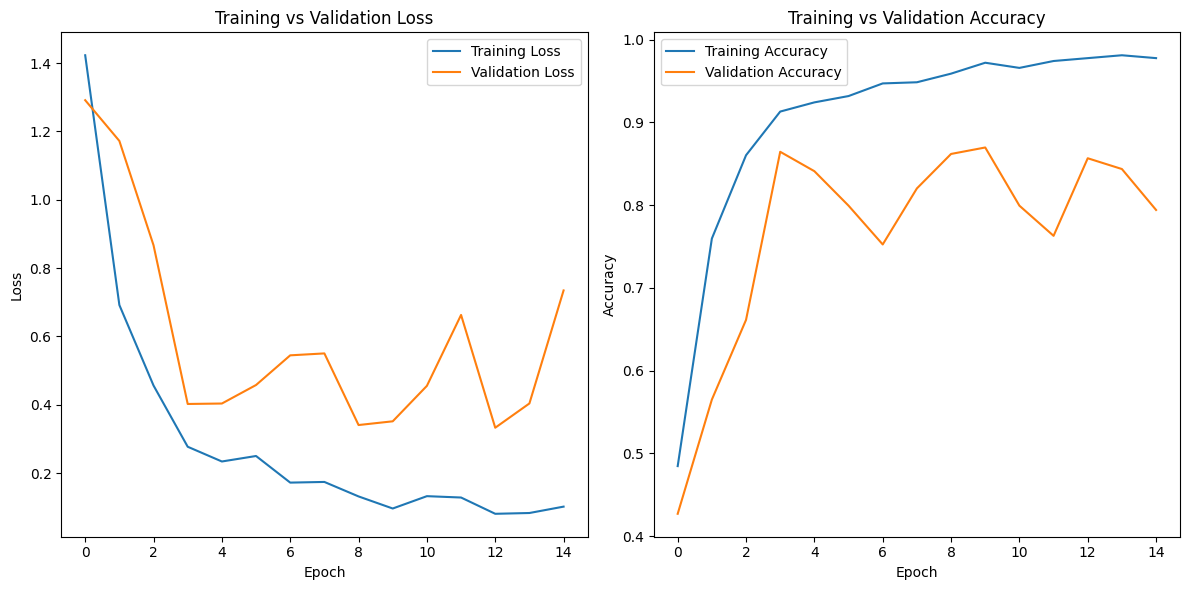

In [ ]:
model = CNN(num_classes).to(device)
train_losses, train_accs, val_losses, val_accs = train(model, num_classes, train_loader, val_loader, num_epochs)

fig, axes = plt.subplots(1,2, figsize=(12,6))

axes[0].plot(train_losses, label="Training Loss")
axes[0].plot(val_losses, label="Validation Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Training vs Validation Loss")
axes[0].legend()

axes[1].plot(train_accs, label="Training Accuracy")
axes[1].plot(val_accs, label="Validation Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Training vs Validation Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()

**Overfitting:** Yes. Training accuracy climbs to ~98% (loss ~0.08-0.13) while validation loss bottoms out around epoch 9-10 (≈0.34, val acc ≈0.87) then turns noisy and trends back up (spiking to 0.73 by epoch 15) even as training loss keeps falling. Overfitting onset: roughly epoch 9-10

### 6. Per-class evaluation: which defect type has the lowest F1 score on the test set? Look at misclassified examples — why might crazing and patches be confused?

In [ ]:
def evaluate_model(model, loader):

  all_preds, all_labels = [], []
  misclassified_images, misclassified_true, misclassified_preds = [], [], []

  model.eval()
  with torch.no_grad():
    for images, labels in loader:
      images, labels = images.to(device), labels.to(device)

      outputs = model(images)
      preds = outputs.argmax(dim=1)


      all_preds.extend(preds.cpu().numpy())
      all_labels.extend(labels.cpu().numpy())

      wrong_mask = (preds != labels)

      if wrong_mask.any():
        misclassified_images.extend(images[wrong_mask].cpu())
        misclassified_preds.extend(preds[wrong_mask].cpu().numpy())
        misclassified_true.extend(labels[wrong_mask].cpu().numpy())


  return all_preds, all_labels, misclassified_images, misclassified_true, misclassified_preds



In [ ]:
all_preds, all_labels, misclassified_images, misclassified_true, misclassified_preds = evaluate_model(model, val_loader)
print(classification_report(all_labels, all_preds, target_names = class_names))

                 precision    recall  f1-score   support

        crazing       0.86      0.90      0.88        60
      inclusion       0.94      0.57      0.71        60
        patches       0.81      0.73      0.77        60
 pitted_surface       0.69      0.95      0.80        60
rolled-in_scale       0.80      1.00      0.89        60
      scratches       0.78      0.63      0.70        60

       accuracy                           0.80       360
      macro avg       0.81      0.80      0.79       360
   weighted avg       0.81      0.80      0.79       360



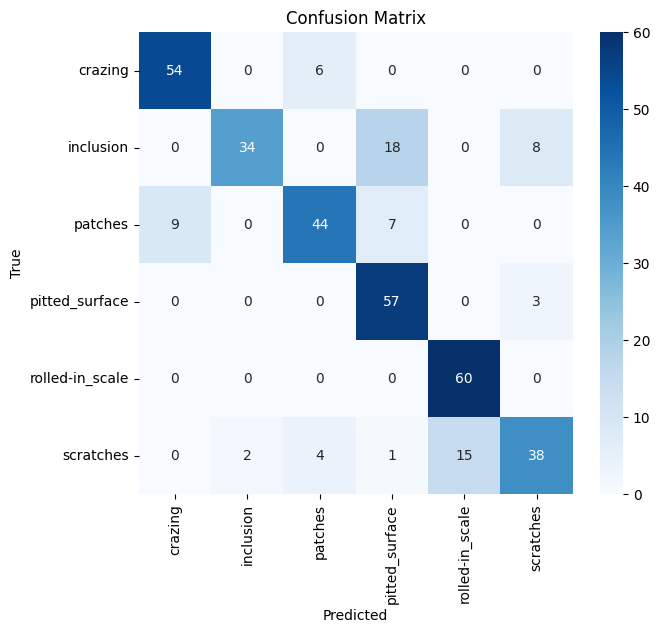

In [ ]:
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

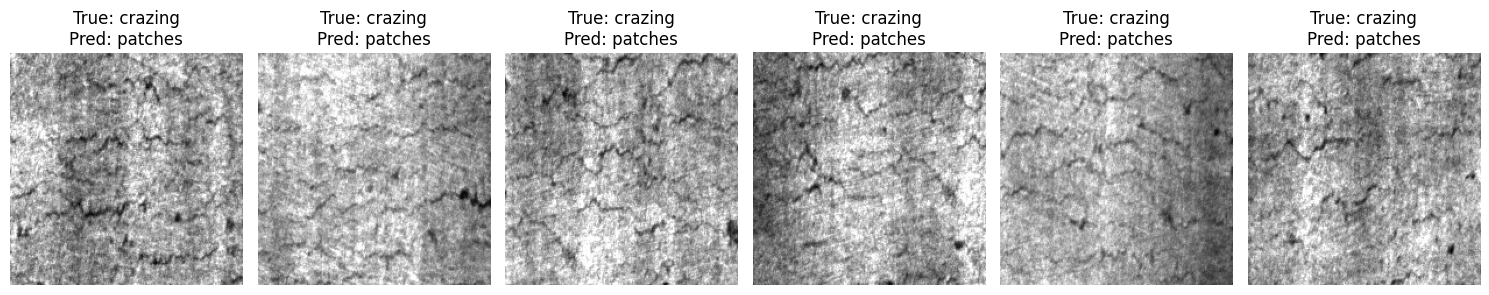

Total misclassified: 73 / 360


In [ ]:
n_show = min(6, len(misclassified_images))
fig, axes = plt.subplots(1, n_show, figsize=(15, 3))
if n_show == 1:
    axes = [axes]

for i in range(n_show):
    img = misclassified_images[i].squeeze().numpy()
    img = (img * 0.5) + 0.5
    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(f"True: {class_names[misclassified_true[i]]}\nPred: {class_names[misclassified_preds[i]]}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()

print(f"Total misclassified: {len(misclassified_images)} / {len(all_labels)}")

**Lowest F1 class:** From the report: crazing 0.88, inclusion 0.71, patches 0.77, pitted_surface 0.80, rolled-in_scale 0.89, scratches 0.70 (lowest).

Crazing and patches get confused because both present as irregular, low-contrast variation (fine networked cracks vs. blotchy discoloration) rather than sharp geometric shapes. A shallow 2-conv-layer network can conflate these texture types, especially without enough filters to pick up on the finer distinguishing detail.

# Part B: Model Hardening


The production line is messy.
Defects appear at any angle, under variable lighting, and at different
positions in the frame. A model trained only on clean, centred images will fail
in deployment.


### 7. Data augmentation: add transforms for the training set only — RandomHorizontalFlip, RandomRotation(15), RandomCrop(180). Do NOT augment the validation/test set. Why?


In [ ]:
train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.RandomCrop(180),
    transforms.Resize((inp_size,inp_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

val_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((inp_size,inp_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

train_dataset_aug = datasets.ImageFolder(train_dir, transform=train_transform)
val_dataset_aug = datasets.ImageFolder(val_dir, transform = val_transform)

train_loader_aug = DataLoader(train_dataset_aug, batch_size=32, shuffle=True)
val_loader_aug = DataLoader(val_dataset_aug, batch_size=32, shuffle=False)

**Why not augment validation:** Augmentation exists to make the model robust to real-world variation seen only during training. The validation set must stay a stable, unmodified yardstick of true generalization. Augmenting validation too would mean evaluating against a constantly shifting target, making epoch-to-epoch and model-to-model comparisons meaningless.

### 8. Batch normalisation: add nn.BatchNorm2d after each Conv2d layer. Retrain. How do the loss curves change compared to Part A? Explain the mechanism.

In [ ]:
class CNN_BN(nn.Module):
    def __init__(self, num_classes, dropout_p = 0.0):
        super(CNN_BN, self).__init__()

        self.conv1 = nn.Conv2d(in_channels = 1, out_channels=16, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(16)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)  # 200x200 -> 100x100

        self.conv2 = nn.Conv2d(in_channels = 16, out_channels=32, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(32)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)  # 100x100 -> 50x50

        self.flatten = nn.Flatten()
        self.dropout = nn.Dropout(dropout_p)  # dropout_p = 0.0 to disable drop out
        self.fc = nn.Linear(32 * 50 * 50, num_classes)

    def forward(self, x):
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu1(out)
        out = self.pool1(out)
        out = self.conv2(out)
        out = self.bn2(out)
        out = self.relu2(out)
        out = self.pool2(out)
        out = self.flatten(out)
        out = self.dropout(out)
        out = self.fc(out)
        return out

model_bn = CNN_BN(num_classes, 0.0)
model_bn

CNN_BN(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu1): ReLU()
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu2): ReLU()
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (dropout): Dropout(p=0.0, inplace=False)
  (fc): Linear(in_features=80000, out_features=6, bias=True)
)

In [ ]:
print("CNN + BN Model Training")
model_bn = CNN_BN(num_classes= num_classes, dropout_p = 0.0).to(device)
train_losses_bn, train_accs_bn, val_losses_bn, val_accs_bn = train(model_bn, num_classes, train_loader, val_loader, num_epochs)

CNN + BN Model Training
Epoch 1/15 | Train Loss: 8.3474, Train Acc: 0.6118 | Val Loss: 25.3683, Val Acc: 0.2135
Epoch 2/15 | Train Loss: 3.0874, Train Acc: 0.7653 | Val Loss: 4.3606, Val Acc: 0.5938
Epoch 3/15 | Train Loss: 2.1137, Train Acc: 0.8076 | Val Loss: 1.7738, Val Acc: 0.7656
Epoch 4/15 | Train Loss: 2.1902, Train Acc: 0.8236 | Val Loss: 1.9179, Val Acc: 0.7708
Epoch 5/15 | Train Loss: 1.3252, Train Acc: 0.8681 | Val Loss: 2.7408, Val Acc: 0.7135
Epoch 6/15 | Train Loss: 1.7327, Train Acc: 0.8479 | Val Loss: 5.3793, Val Acc: 0.6380
Epoch 7/15 | Train Loss: 1.3426, Train Acc: 0.8903 | Val Loss: 0.9479, Val Acc: 0.8620
Epoch 8/15 | Train Loss: 0.7992, Train Acc: 0.9292 | Val Loss: 4.4401, Val Acc: 0.6797
Epoch 9/15 | Train Loss: 0.7755, Train Acc: 0.9153 | Val Loss: 2.2886, Val Acc: 0.7786
Epoch 10/15 | Train Loss: 0.4048, Train Acc: 0.9431 | Val Loss: 1.0988, Val Acc: 0.8021
Epoch 11/15 | Train Loss: 0.6398, Train Acc: 0.9153 | Val Loss: 1.2844, Val Acc: 0.8568
Epoch 12/15 | Tr

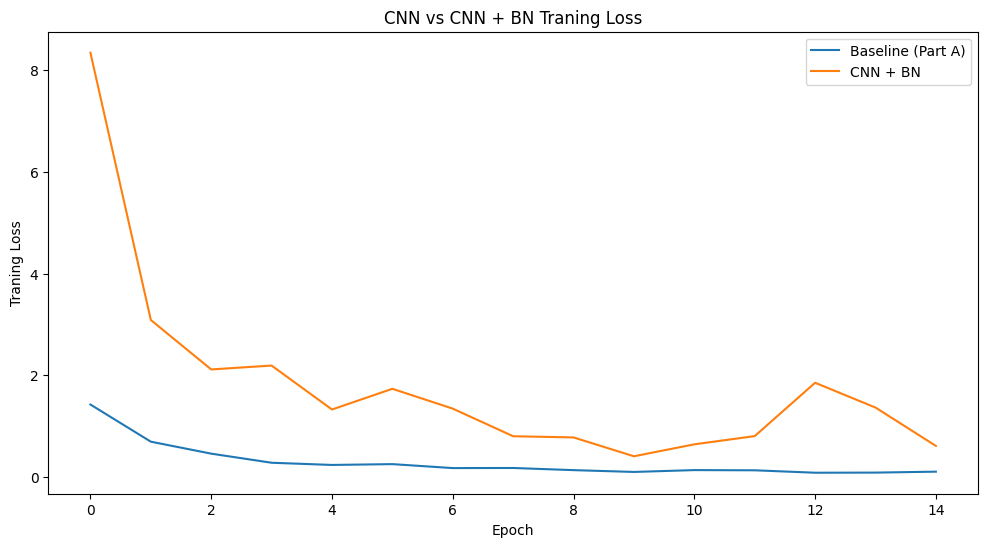

In [ ]:
plt.figure(figsize = (12,6))
plt.plot(train_losses, label='Baseline (Part A)')
plt.plot(train_losses_bn, label='CNN + BN')
plt.xlabel('Epoch')
plt.ylabel('Traning Loss')
plt.title('CNN vs CNN + BN Traning Loss')
plt.legend()
plt.show()

**BN effect on loss curves:** Baseline training loss decreases smoothly (1.42 → ~0.10). The BN run is dramatically more volatile starting at 8.3474, never settling into a smooth decline.

BN's batch statistics are unstable early on with small batches/dataset, and combined with a large 80,000-input fc layer, this produces exactly this spiky pattern before the running statistics have time to stabilize.


### 9. Dropout: add nn.Dropout(0.4) before the final Linear layer. How does this affect overfitting? What is dropout doing during training vs. inference?

In [ ]:
model_bn_dropout = CNN_BN(num_classes= num_classes, dropout_p = 0.4).to(device)
model_bn_dropout

CNN_BN(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu1): ReLU()
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu2): ReLU()
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (dropout): Dropout(p=0.4, inplace=False)
  (fc): Linear(in_features=80000, out_features=6, bias=True)
)

### 10.  Plot all three configurations (Part A baseline, +augmentation, +augmentation+BN+dropout) on the same validation accuracy graph. Which combination performs best?

In [ ]:
print("CNN + Augmentation Model Training")
model_cnn = CNN(num_classes).to(device)
train_losses_cnn_aug, train_accs_cnn_aug, val_losses_cnn_aug, val_accs_cnn_aug = train(model_cnn, num_classes, train_loader_aug, val_loader_aug, num_epochs)

print("CNN + Augmentation + BN Model Training")
model_bn = CNN_BN(num_classes= num_classes, dropout_p = 0.0).to(device)
train_losses_bn_aug, train_accs_bn_aug, val_losses_bn_aug, val_accs_bn_aug = train(model_bn, num_classes, train_loader_aug, val_loader_aug, num_epochs)

print("CNN + Augmentation + BN + Dropout Model Training")
train_losses_bn_dropout_aug, train_accs_bn_dropout_aug, val_losses_bn_dropout_aug, val_accs_bn_dropout_aug = train(model_bn_dropout, num_classes, train_loader_aug, val_loader_aug, num_epochs)

CNN + Augmentation Model Training
Epoch 1/15 | Train Loss: 1.5034, Train Acc: 0.4806 | Val Loss: 1.5677, Val Acc: 0.4271
Epoch 2/15 | Train Loss: 0.8662, Train Acc: 0.7215 | Val Loss: 1.2924, Val Acc: 0.4870
Epoch 3/15 | Train Loss: 0.6768, Train Acc: 0.7778 | Val Loss: 1.1184, Val Acc: 0.6094
Epoch 4/15 | Train Loss: 0.5625, Train Acc: 0.8326 | Val Loss: 1.1222, Val Acc: 0.6172
Epoch 5/15 | Train Loss: 0.4980, Train Acc: 0.8486 | Val Loss: 1.1307, Val Acc: 0.5625
Epoch 6/15 | Train Loss: 0.3633, Train Acc: 0.8812 | Val Loss: 0.9266, Val Acc: 0.6120
Epoch 7/15 | Train Loss: 0.3621, Train Acc: 0.8792 | Val Loss: 0.9300, Val Acc: 0.6224
Epoch 8/15 | Train Loss: 0.3290, Train Acc: 0.8910 | Val Loss: 1.6518, Val Acc: 0.5130
Epoch 9/15 | Train Loss: 0.3607, Train Acc: 0.8889 | Val Loss: 0.8879, Val Acc: 0.6615
Epoch 10/15 | Train Loss: 0.2913, Train Acc: 0.9056 | Val Loss: 1.0894, Val Acc: 0.6146
Epoch 11/15 | Train Loss: 0.2692, Train Acc: 0.9083 | Val Loss: 1.3433, Val Acc: 0.5625
Epoch 1

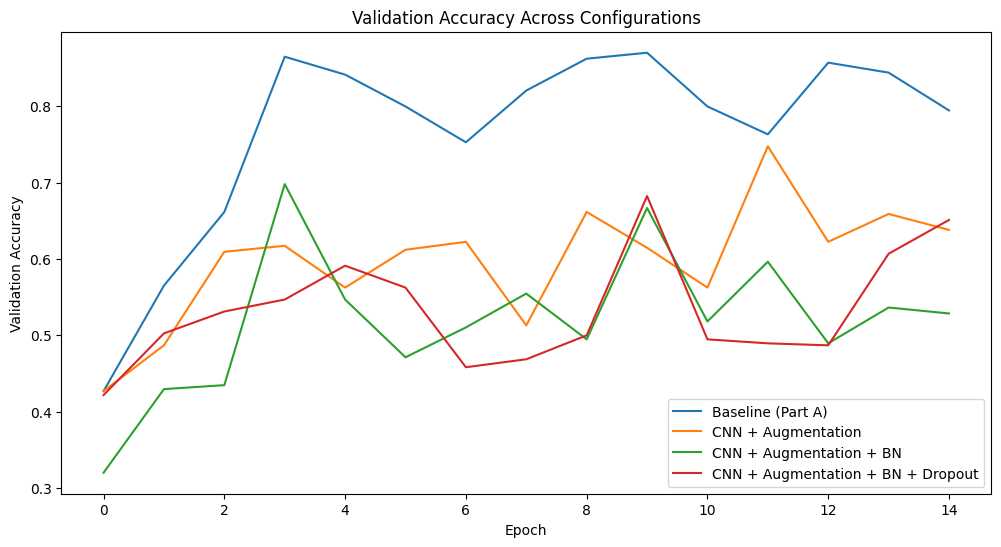

In [ ]:
plt.figure(figsize = (12,6))
plt.plot(val_accs, label='Baseline (Part A)')
plt.plot(val_accs_cnn_aug, label='CNN + Augmentation')
plt.plot(val_accs_bn_aug, label='CNN + Augmentation + BN')
plt.plot(val_accs_bn_dropout_aug, label='CNN + Augmentation + BN + Dropout')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.title('Validation Accuracy Across Configurations')
plt.legend()
plt.show()

**Dropout effect:** Comparing BN-only vs BN+Dropout final epochs, both remain volatile, but BN+Dropout's peak val acc (0.68 at epoch 10) is somewhat more consistent across epochs than BN-alone's (which collapses to 0.53 by epoch 15). Dropout randomly zeroes 40% of units feeding the final layer during training only, forcing the network not to over-rely on specific feature combinations. During training units are randomly masked and survivors scaled by 1/(1-p). During inference (model.eval()): dropout is fully disabled. All units active, no masking, no scaling, which is why calling .eval() before evaluation is essential.

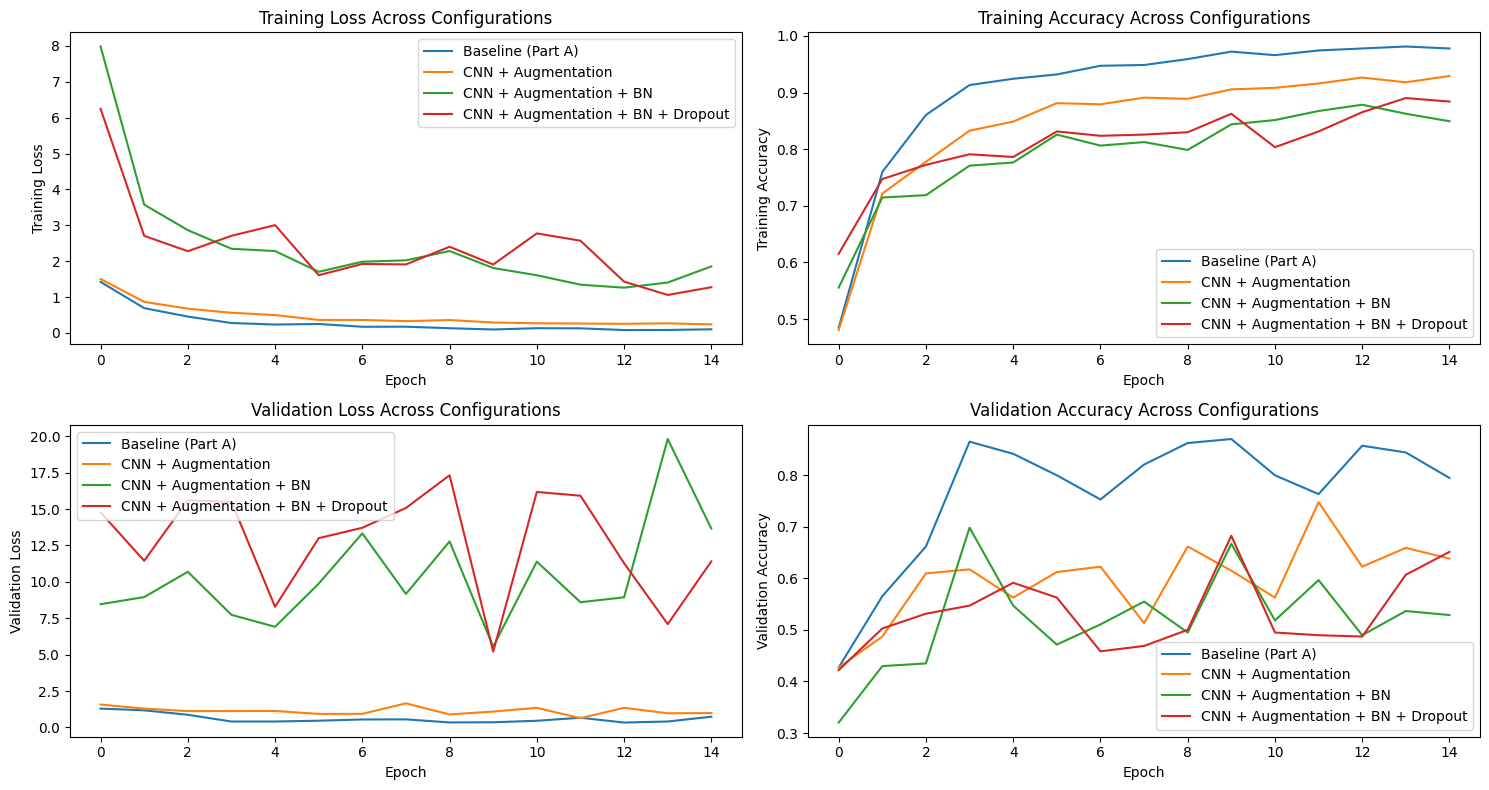

In [ ]:
plt.figure(figsize=(15,8))

plt.subplot(2,2,1)
plt.plot(train_losses, label='Baseline (Part A)')
plt.plot(train_losses_cnn_aug, label='CNN + Augmentation')
plt.plot(train_losses_bn_aug, label='CNN + Augmentation + BN')
plt.plot(train_losses_bn_dropout_aug, label='CNN + Augmentation + BN + Dropout')
plt.xlabel('Epoch')
plt.ylabel('Training Loss')
plt.title('Training Loss Across Configurations')
plt.legend()

plt.subplot(2,2,2)
plt.plot(train_accs, label='Baseline (Part A)')
plt.plot(train_accs_cnn_aug, label='CNN + Augmentation')
plt.plot(train_accs_bn_aug, label='CNN + Augmentation + BN')
plt.plot(train_accs_bn_dropout_aug, label='CNN + Augmentation + BN + Dropout')
plt.xlabel('Epoch')
plt.ylabel('Training Accuracy')
plt.title('Training Accuracy Across Configurations')
plt.legend()


plt.subplot(2,2,3)
plt.plot(val_losses, label='Baseline (Part A)')
plt.plot(val_losses_cnn_aug, label='CNN + Augmentation')
plt.plot(val_losses_bn_aug, label='CNN + Augmentation + BN')
plt.plot(val_losses_bn_dropout_aug, label='CNN + Augmentation + BN + Dropout')
plt.xlabel('Epoch')
plt.ylabel('Validation Loss')
plt.title('Validation Loss Across Configurations')
plt.legend()


plt.subplot(2,2,4)
plt.plot(val_accs, label='Baseline (Part A)')
plt.plot(val_accs_cnn_aug, label='CNN + Augmentation')
plt.plot(val_accs_bn_aug, label='CNN + Augmentation + BN')
plt.plot(val_accs_bn_dropout_aug, label='CNN + Augmentation + BN + Dropout')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.title('Validation Accuracy Across Configurations')
plt.legend()

plt.tight_layout()
plt.show()

The plain baseline wins on both final and peak validation accuracy in this run A genuinely interesting result. BN and Dropout each add their own training-time noise (batch statistics, random masking), and stacked with augmentation this compounds into the instability. 15 epochs isn't enough for these techniques to "pay off" their generalization benefit here. "More regularization" didn't automatically win within this training budget

### 11.  Reflection:
if you could only apply one technique from this part to a new manufacturing
dataset, which would you choose and why?

If limited to one technique for a new manufacturing dataset with messy real-world conditions, augmentation is the strongest choice. It's the only one of the three that directly targets the actual stated problem (input variability itself: angle, lighting, position), rather than internal training dynamics. Augmentation alone (0.638) held up better than BN stacked on top of it (0.529).

# Part C: Hyperparameter Tuning

### 12.  Grid search: train your best model from Part B with all combinations of learning rate in `{0.001, 0.01}` and batch size in `{16, 32}`. Record validation accuracy for each of the 4 combinations.

In [ ]:
import itertools

learning_rate = [0.001, 0.01]
batch_size = [16, 32]

results = []

for lr, bs in itertools.product(learning_rate, batch_size):
  print(f"\n=== Training with lr={lr}, batch_size={bs} ===")

  train_loader_grid = DataLoader(train_dataset_aug, batch_size=bs, shuffle=True)
  val_loader_grid = DataLoader(val_dataset_aug, batch_size=bs, shuffle=False)

  model_grid = CNN_BN(num_classes=num_classes, dropout_p=0.4).to(device)

  _, _, _, val_accs_grid = train(model_grid, num_classes, train_loader_grid, val_loader_grid, num_epochs, lr)

  print(f"Final val accuracy: {val_accs_grid[-1]:.4f}")
  results.append({'lr': lr, 'batch_size': bs, 'val_acc': val_accs_grid[-1]})


=== Training with lr=0.001, batch_size=16 ===
Epoch 1/15 | Train Loss: 8.5158, Train Acc: 0.6000 | Val Loss: 10.0460, Val Acc: 0.4918
Epoch 2/15 | Train Loss: 3.6674, Train Acc: 0.7410 | Val Loss: 7.5355, Val Acc: 0.6087
Epoch 3/15 | Train Loss: 3.0231, Train Acc: 0.7660 | Val Loss: 4.2006, Val Acc: 0.6549
Epoch 4/15 | Train Loss: 3.5609, Train Acc: 0.7646 | Val Loss: 11.0825, Val Acc: 0.6821
Epoch 5/15 | Train Loss: 3.2093, Train Acc: 0.7826 | Val Loss: 3.4138, Val Acc: 0.7962
Epoch 6/15 | Train Loss: 2.6647, Train Acc: 0.8097 | Val Loss: 7.3816, Val Acc: 0.5870
Epoch 7/15 | Train Loss: 1.9799, Train Acc: 0.8326 | Val Loss: 19.1897, Val Acc: 0.5000
Epoch 8/15 | Train Loss: 2.2246, Train Acc: 0.8271 | Val Loss: 5.9940, Val Acc: 0.7500
Epoch 9/15 | Train Loss: 1.8807, Train Acc: 0.8521 | Val Loss: 4.5651, Val Acc: 0.8370
Epoch 10/15 | Train Loss: 1.7025, Train Acc: 0.8604 | Val Loss: 10.2088, Val Acc: 0.5652
Epoch 11/15 | Train Loss: 1.4162, Train Acc: 0.8701 | Val Loss: 5.1450, Val Ac

### 13.  Present results as a markdown table. Which combination performed best? Which hyperparameter had more impact?

In [ ]:
grid_df = pd.DataFrame(results)
print(grid_df.to_markdown(index=False))

|    lr |   batch_size |   val_acc |
|------:|-------------:|----------:|
| 0.001 |           16 |  0.69837  |
| 0.001 |           32 |  0.414062 |
| 0.01  |           16 |  0.557065 |
| 0.01  |           32 |  0.682292 |


**Best combination:** `lr=0.001, batch_size=16`. Neither hyperparameter dominates cleanly. They interact: at batch_size=16, lower lr wins (0.698 > 0.557); at batch_size=32, the opposite holds (0.682 > 0.414). The average swing from varying each (≈0.20 for both) is roughly comparable. This is a real interaction effect rather than one hyperparameter being clearly more important.

### 14. Learning rate schedule: add torch.optim.lr_scheduler.StepLR (step every 5 epochs, gamma=0.5) to your best run. Does it improve final test accuracy?



In [ ]:

best_lr = 0.001
best_bs = 16

train_loader_best = DataLoader(train_dataset_aug, batch_size=best_bs, shuffle=True)
val_loader_best   = DataLoader(val_dataset_aug, batch_size=best_bs, shuffle=False)

model_best = CNN_BN(num_classes=num_classes, dropout_p=0.4).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_best.parameters(), lr=best_lr)
scheduler = StepLR(optimizer, step_size=5, gamma=0.5)

val_accs_scheduled = []
for epoch in range(num_epochs):
    model_best.train()
    for images, labels in train_loader_best:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model_best(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

    scheduler.step()  # decay LR after each epoch (checks internally if it's a step epoch)

    _, val_acc = evaluate(model_best, val_loader_best, criterion)
    val_accs_scheduled.append(val_acc)
    print(f"Epoch {epoch+1}/15 | LR: {scheduler.get_last_lr()[0]:.5f} | Val Acc: {val_acc:.4f}")

print(f"\nFinal val accuracy with StepLR: {val_accs_scheduled[-1]:.4f}")
print(f"Final val accuracy without scheduler (from grid search): {grid_df[(grid_df.lr==best_lr) & (grid_df.batch_size==best_bs)]['val_acc'].values[0]:.4f}")

Epoch 1/15 | LR: 0.00100 | Val Acc: 0.4293
Epoch 2/15 | LR: 0.00100 | Val Acc: 0.5978
Epoch 3/15 | LR: 0.00100 | Val Acc: 0.4973
Epoch 4/15 | LR: 0.00100 | Val Acc: 0.4375
Epoch 5/15 | LR: 0.00050 | Val Acc: 0.5571
Epoch 6/15 | LR: 0.00050 | Val Acc: 0.5217
Epoch 7/15 | LR: 0.00050 | Val Acc: 0.5815
Epoch 8/15 | LR: 0.00050 | Val Acc: 0.5245
Epoch 9/15 | LR: 0.00050 | Val Acc: 0.6250
Epoch 10/15 | LR: 0.00025 | Val Acc: 0.6005
Epoch 11/15 | LR: 0.00025 | Val Acc: 0.6141
Epoch 12/15 | LR: 0.00025 | Val Acc: 0.6141
Epoch 13/15 | LR: 0.00025 | Val Acc: 0.5380
Epoch 14/15 | LR: 0.00025 | Val Acc: 0.6440
Epoch 15/15 | LR: 0.00013 | Val Acc: 0.5679

Final val accuracy with StepLR: 0.5679
Final val accuracy without scheduler (from grid search): 0.6984


**Does StepLR help?** No, final val acc with StepLR was 0.568, worse than the no-scheduler baseline of 0.698 at the same settings. Halving every 5 epochs over just 15 epochs total drops lr to ~0.000125 by the end. Too aggressive a decay for such a short run, cutting off learning before the higher early lr could be fully exploited.

15.  **Extended** — Bayesian optimisation: use Optuna to search over lr (1e-4 to 1e-1,
log-uniform) and batch size (8 to 64). Does it find a better combination than
your grid search?

In [ ]:

def objective(trial):
  lr = trial.suggest_float('lr', 1e-4, 1e-1, log=True)
  batch_size = trial.suggest_categorical('batch_size', [8, 16, 32, 64])

  train_loader_trial = DataLoader(train_dataset_aug, batch_size=batch_size, shuffle=True)
  val_loader_trial = DataLoader(val_dataset_aug, batch_size=batch_size, shuffle=True)

  model_trial = CNN_BN(num_classes=num_classes, dropout_p=0.4).to(device)

  criterion = nn.CrossEntropyLoss()
  optimizer = optim.Adam(model_trial.parameters(), lr=lr)

  val_acc_final = 0.0
  for epoch in range(num_epochs):
      model_trial.train()
      for images, labels in train_loader_trial:
          images, labels = images.to(device), labels.to(device)
          optimizer.zero_grad()
          outputs = model_trial(images)
          loss = criterion(outputs, labels)
          loss.backward()
          optimizer.step()

      _, val_acc_final = evaluate(model_trial, val_loader_trial, criterion)

      trial.report(val_acc_final, epoch)
      if trial.should_prune():
          raise optuna.TrialPruned()

  return val_acc_final

study = optuna.create_study(direction='maximize', pruner=optuna.pruners.MedianPruner())
study.optimize(objective, n_trials=30)

print("\nBest trial:")
print(f"  Val accuracy: {study.best_value:.4f}")
print(f"  Params: {study.best_params}")

[I 2026-07-08 12:07:24,306] A new study created in memory with name: no-name-b72e5cd8-9f26-4e9d-949b-16bdb1b3e4eb
[I 2026-07-08 12:08:11,214] Trial 0 finished with value: 0.5729166666666666 and parameters: {'lr': 0.00038925232099804686, 'batch_size': 32}. Best is trial 0 with value: 0.5729166666666666.
[I 2026-07-08 12:08:58,822] Trial 1 finished with value: 0.6041666666666666 and parameters: {'lr': 0.0012670731167532634, 'batch_size': 32}. Best is trial 1 with value: 0.6041666666666666.
[I 2026-07-08 12:09:46,825] Trial 2 finished with value: 0.3641304347826087 and parameters: {'lr': 0.009855842496685531, 'batch_size': 16}. Best is trial 1 with value: 0.6041666666666666.
[I 2026-07-08 12:10:31,954] Trial 3 finished with value: 0.4869791666666667 and parameters: {'lr': 0.010145214051459012, 'batch_size': 64}. Best is trial 1 with value: 0.6041666666666666.
[I 2026-07-08 12:11:18,402] Trial 4 finished with value: 0.1640625 and parameters: {'lr': 0.05330552497673021, 'batch_size': 32}. B


Best trial:
  Val accuracy: 0.6848
  Params: {'lr': 0.0007611273333866625, 'batch_size': 16}


In [ ]:
print(f"Grid search best: {grid_df['val_acc'].max():.4f}  (params: {grid_df.loc[grid_df['val_acc'].idxmax()].to_dict()})")
print(f"Optuna best:       {study.best_value:.4f}  (params: {study.best_params})")

Grid search best: 0.6984  (params: {'lr': 0.001, 'batch_size': 16.0, 'val_acc': 0.6983695652173914})
Optuna best:       0.6848  (params: {'lr': 0.0007611273333866625, 'batch_size': 16})


**Optuna vs grid search:** Optuna's best was 0.685 (lr≈0.00076, bs=16), actually slightly below the grid search's 0.698. The grid search happened to test a point very close to optimal, and given the high run-to-run noise in this setup (each trial is a single training run), 30 Optuna trials landing marginally below one grid point is well within expected variance and is not an evidence Optuna "failed."

In [ ]:
import optuna.visualization as vis

vis.plot_optimization_history(study).show()
vis.plot_param_importances(study).show()